<a href="https://colab.research.google.com/github/NishkaArora/CN_recommendation_CS329H/blob/main/Appendix_Note_CS329H_Final_Project_CN_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title Import Packages

from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np # for closed form
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, Dataset

import statsmodels.api as sm
import statsmodels.formula.api as smf

import time

DATA_DIR = "/content/drive/MyDrive/CN_CS329H_DATA/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load + Preprocess Data

In [2]:
# @title Notes data

notes_path = DATA_DIR + "notes-00000-2.tsv"
notes_df = pd.read_csv(notes_path, sep = '\t')
print("notes.csv loaded successfully.")
display(notes_df.head(3))

/tmp/ipython-input-4210992157.py:4: DtypeWarning: Columns (5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  notes_df = pd.read_csv(notes_path, sep = '\t')


notes.csv loaded successfully.


,noteId,noteAuthorParticipantId,createdAtMillis,tweetId,classification,believable,harmful,validationDifficulty,misleadingOther,misleadingFactualError,...,misleadingUnverifiedClaimAsFact,misleadingSatire,notMisleadingOther,notMisleadingFactuallyCorrect,notMisleadingOutdatedButNotWhenWritten,notMisleadingClearlySatire,notMisleadingPersonalOpinion,trustworthySources,summary,isMediaNote
0,1783179305159200982,C784F04F26E124F4D6EC01658D8F5565005D3092741FB3...,1713978050878,1783159712986382830,MISINFORMED_OR_POTENTIALLY_MISLEADING,NaN,NaN,NaN,0,0,...,0,0,0,0,0,0,0,1,The House failed to pass a border protection l...,0
1,1783181538789605871,C784F04F26E124F4D6EC01658D8F5565005D3092741FB3...,1713978583415,1783171851818021181,MISINFORMED_OR_POTENTIALLY_MISLEADING,NaN,NaN,NaN,0,1,...,1,0,0,0,0,0,0,1,The United States has 50 States https://da...,0
2,1783182562279494134,C784F04F26E124F4D6EC01658D8F5565005D3092741FB3...,1713978827435,1783154445682979015,MISINFORMED_OR_POTENTIALLY_MISLEADING,NaN,NaN,NaN,0,0,...,0,0,0,0,0,0,0,1,TikTok only mentions “ban” and chooses to igno...,0


In [3]:
# @title Note Status Data

note_status_history = pd.read_csv(DATA_DIR + "noteStatusHistory-00000-2.tsv", sep = '\t')
print("noteStatusHistory-00000-2.tsv loaded successfully.")
display(note_status_history.head(3))

/tmp/ipython-input-839875861.py:3: DtypeWarning: Columns (10,19) have mixed types. Specify dtype option on import or set low_memory=False.
  note_status_history = pd.read_csv(DATA_DIR + "noteStatusHistory-00000-2.tsv", sep = '\t')


noteStatusHistory-00000-2.tsv loaded successfully.


,noteId,noteAuthorParticipantId,createdAtMillis,timestampMillisOfFirstNonNMRStatus,firstNonNMRStatus,timestampMillisOfCurrentStatus,currentStatus,timestampMillisOfLatestNonNMRStatus,mostRecentNonNMRStatus,timestampMillisOfStatusLock,...,currentExpansionStatus,currentGroupStatus,currentDecidedBy,currentModelingGroup,timestampMillisOfMostRecentStatusChange,timestampMillisOfNmrDueToMinStableCrhTime,currentMultiGroupStatus,currentModelingMultiGroup,timestampMinuteOfFinalScoringOutput,timestampMillisOfFirstNmrDueToMinStableCrhTime
0,1352796878438424576,B021517F4F8F9F372DCD70BB8F8A21A80C12D7EFDE8B2F...,1611366884227,NaN,NaN,1721920068424,NEEDS_MORE_RATINGS,NaN,NaN,1.674003e+12,...,NEEDS_MORE_RATINGS,NEEDS_MORE_RATINGS,CoreModel (v1.1),13.0,-1,NaN,NaN,NaN,29259590,NaN
1,1353415873227177985,D4C9EDB464DF2D4A6D8F68CA8D1F86226B50EB9D3B0F33...,1611514464087,NaN,NaN,1721920068424,NEEDS_MORE_RATINGS,NaN,NaN,1.674003e+12,...,NEEDS_MORE_RATINGS,NEEDS_MORE_RATINGS,CoreModel (v1.1),13.0,-1,NaN,NaN,NaN,29259590,NaN
2,1354586938863443971,C0AF45F4C4B2240E7AB31456957E5D770FF7AFA13627C7...,1611793667892,NaN,NaN,1721920068424,NEEDS_MORE_RATINGS,NaN,NaN,1.674003e+12,...,NEEDS_MORE_RATINGS,NEEDS_MORE_RATINGS,CoreModel (v1.1),6.0,-1,NaN,NaN,NaN,29259590,NaN


In [4]:
# @title Ratings data

# notes decided by the core-model
core_notes_path = DATA_DIR+"core_notes.csv"

try:
    core_notes_df = pd.read_csv(core_notes_path)
    print("core_notes.csv loaded successfully.")
    display(core_notes_df.head())
except FileNotFoundError:
    print(f"Error: {core_notes_path} not found. Please ensure the file exists in the specified path.")
except Exception as e:
    print(f"An error occurred while loading {core_notes_path}: {e}")

OUTPUT_CSV_TEMPLATE = DATA_DIR+"filtered_data/ratings_{}.csv"

months = ['May', 'June', 'July', 'August', 'September', 'October']

all_ratings_df = []

columns_to_drop = ['notHelpfulNoteNotNeeded', 'ratedOnTweetId']

for month in months:
    csv_path = OUTPUT_CSV_TEMPLATE.format(month)
    try:
        ratings_df_month = pd.read_csv(csv_path)

        ratings_df_month = ratings_df_month.dropna(subset=['helpfulnessLevel'])

        ratings_df_month = ratings_df_month.drop(columns=columns_to_drop, errors='ignore') # Use errors='ignore' in case a column is missing in a file

        # Filter by core notes BEFORE appending to the list
        ratings_df_month = ratings_df_month[ratings_df_month['noteId'].isin(core_notes_df['noteId'])]

        all_ratings_df.append(ratings_df_month)
    except FileNotFoundError:
        print(f"Warning: {csv_path} not found. Skipping.")
    except Exception as e:
        print(f"An error occurred while processing {csv_path}: {e}")

ratings_df = pd.concat(all_ratings_df, ignore_index=True)

print(f"Number of ratings after loading and core-notes filtering: {len(ratings_df)}")
ratings_df.info()

core_notes.csv loaded successfully.


,noteId
0,1352796878438424576
1,1353415873227177985
2,1354586938863443971
3,1354602688097308676
4,1354630645385846789


Number of ratings after loading and core-notes filtering: 47266967
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47266967 entries, 0 to 47266966
Data columns (total 4 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   noteId              int64 
 1   raterParticipantId  object
 2   createdAtMillis     object
 3   helpfulnessLevel    object
dtypes: int64(1), object(3)
memory usage: 1.4+ GB


In [5]:
# @title Map Ratings to Float

rating_map = {'HELPFUL': 1, 'NOT_HELPFUL': 0, 'SOMEWHAT_HELPFUL': 0.5}

ratings_df['rating'] = ratings_df['helpfulnessLevel'].map(rating_map)

In [6]:
# @title Assign Note ID and Rater ID

# Create unique IDs for notes and raters
note_ids = ratings_df['noteId'].astype('category').cat.codes
rater_ids = ratings_df['raterParticipantId'].astype('category').cat.codes

# Print the number of unique notes and raters
num_notes = len(ratings_df['noteId'].unique())
num_raters = len(ratings_df['raterParticipantId'].unique())
print(f"Number of unique notes: {num_notes}")
print(f"Number of unique raters: {num_raters}")

Number of unique notes: 573234
Number of unique raters: 827037


In [7]:
import pandas as pd

# ---- Config ----
SPLIT_DATE_START = pd.to_datetime("2024-10-01")  # inclusive
SPLIT_DATE_END   = pd.to_datetime("2024-10-02")  # exclusive

MIN_RATINGS_PER_NOTE = 5
MIN_RATINGS_PER_RATER = 100

# ---- Prep ----
notes_df = notes_df.copy()
ratings_df = ratings_df.copy()

notes_df["createdAtMillis_dt"] = pd.to_datetime(notes_df["createdAtMillis"], unit="ms")

# ---- 1. Split notes by creation time ----
prev_notes = notes_df[notes_df["createdAtMillis_dt"] < SPLIT_DATE_START]
candidate_notes = notes_df[
    (notes_df["createdAtMillis_dt"] >= SPLIT_DATE_START)
    & (notes_df["createdAtMillis_dt"] < SPLIT_DATE_END)
]

# ---- 2. Split ratings by whether they refer to prev vs candidate notes ----
D0 = ratings_df[ratings_df["noteId"].isin(prev_notes["noteId"])]  # historical ratings
candidate_ratings = ratings_df[ratings_df["noteId"].isin(candidate_notes["noteId"])]

# ---- 3. Filter candidate notes by having enough ratings ----
note_counts = candidate_ratings["noteId"].value_counts()
valid_note_ids = note_counts[note_counts >= MIN_RATINGS_PER_NOTE].index

candidate_notes = candidate_notes[candidate_notes["noteId"].isin(valid_note_ids)]
candidate_ratings = candidate_ratings[candidate_ratings["noteId"].isin(valid_note_ids)]

# ---- 4. Filter by rater activity (using history D0) ----
rater_counts = D0["raterParticipantId"].value_counts()
active_raters = rater_counts[rater_counts >= MIN_RATINGS_PER_RATER].index

remaining_ratings = candidate_ratings[
    candidate_ratings["raterParticipantId"].isin(active_raters)
]

# Recompute valid notes after dropping inactive raters
valid_note_ids = candidate_ratings["noteId"].unique()
candidate_notes = candidate_notes[candidate_notes["noteId"].isin(valid_note_ids)]

print(f"Candidate notes after filtering: {len(candidate_notes)}")

Candidate notes after filtering: 2042


In [8]:
print(f"number of raters: {len(remaining_ratings['raterParticipantId'].unique())}, number of ratings: {remaining_ratings.shape[0]}")

number of raters: 34148, number of ratings: 159224


In [9]:
#@title get the "true" note status from the CN dataset

status_map = {
    'NEEDS_MORE_RATINGS': 'NMR',
    'CURRENTLY_RATED_HELPFUL': 'CRH',
    'CURRENTLY_RATED_NOT_HELPFUL': 'CRNH'
}

# Merge currentStatus into candidate_notes
# We use a left merge to keep all candidate_notes.
# Notes not found in history will result in NaN (or you can assume NMR).
candidate_notes = candidate_notes.merge(
    note_status_history[['noteId', 'currentStatus']],
    on='noteId',
    how='left'
)

# 3. Map the long status strings to the abbreviations
candidate_notes['currentStatus'] = candidate_notes['currentStatus'].map(status_map)

# 4. Print the counts
print("Status Counts for Candidate Notes:")
print(candidate_notes['currentStatus'].value_counts())

Status Counts for Candidate Notes:
currentStatus
NMR     1776
CRH      180
CRNH      86
Name: count, dtype: int64


In [10]:
# We want specific counts for each status
TARGET_COUNTS = {
    'CRH': 100,   # Helpful
    'CRNH': 10,   # Not Helpful
    'NMR': 200     # Needs More Ratings
}

# 1. Separate notes by status
notes_crh = candidate_notes[candidate_notes['currentStatus'] == 'CRH']
notes_crnh = candidate_notes[candidate_notes['currentStatus'] == 'CRNH']
notes_nmr = candidate_notes[candidate_notes['currentStatus'] == 'NMR']

print(f"Available pools: CRH={len(notes_crh)}, CRNH={len(notes_crnh)}, NMR={len(notes_nmr)}")

# 2. Sample from each group
# We use min() to avoid errors if the requested count is higher than available (though your dataset has enough)
sampled_crh = notes_crh.sample(n=min(TARGET_COUNTS['CRH'], len(notes_crh)), random_state=42)
sampled_crnh = notes_crnh.sample(n=min(TARGET_COUNTS['CRNH'], len(notes_crnh)), random_state=42)
sampled_nmr = notes_nmr.sample(n=min(TARGET_COUNTS['NMR'], len(notes_nmr)), random_state=42)

# 3. Combine into the small candidate set
candidate_notes = pd.concat([sampled_crh, sampled_crnh, sampled_nmr])

remaining_ratings = remaining_ratings[remaining_ratings['noteId'].isin(candidate_notes['noteId'])]

Available pools: CRH=180, CRNH=86, NMR=1776


In [11]:
print(f"Candidate notes after subsampling: {len(candidate_notes)}")
print(f"Remaining ratings after subsampling: {len(remaining_ratings)}")
print(f"Remaining raters after subsampling: {len(remaining_ratings['raterParticipantId'].unique())}")

Candidate notes after subsampling: 310
Remaining ratings after subsampling: 24237
Remaining raters after subsampling: 13875


## Compute full MF for D0

In [12]:
# @title Trim the dataset (remove all notes and raters with < 20 ratings) and train the MF 1 latent dim model

THRESH_NOTES = 20
THRESH_RATERS = 20

# Calculate counts on the full training set
note_counts = D0['noteId'].value_counts()
rater_counts = D0['raterParticipantId'].value_counts()

# Identify valid IDs (Single Pass)
# We determine "validity" based solely on the initial counts
valid_notes = note_counts[note_counts >= THRESH_NOTES].index
valid_raters = rater_counts[rater_counts >= THRESH_RATERS].index

# Filter the dataset
# Keep rows where BOTH the note and rater meet the threshold
train_ratings_trimmed = D0[
    D0['noteId'].isin(valid_notes) &
    D0['raterParticipantId'].isin(valid_raters)
].copy()

print(f"Original training size: {len(D0)}")
print(f"Trimmed training size: {len(train_ratings_trimmed)}")

# Create dictionaries to map original IDs to 0..N-1
unique_notes = train_ratings_trimmed['noteId'].unique()
unique_raters = train_ratings_trimmed['raterParticipantId'].unique()

note_id_to_idx = {nid: i for i, nid in enumerate(unique_notes)}
rater_id_to_idx = {rid: i for i, rid in enumerate(unique_raters)}

print(f"Unique Notes: {len(unique_notes)}")
print(f"Unique Raters: {len(unique_raters)}")

# This maps the string IDs in the dataframe to the integers we just defined
train_ratings_trimmed['note_idx'] = train_ratings_trimmed['noteId'].map(note_id_to_idx)
train_ratings_trimmed['rater_idx'] = train_ratings_trimmed['raterParticipantId'].map(rater_id_to_idx)

# Ensure indices are Long (int64) and ratings are Float (float32)
note_tensor = torch.tensor(train_ratings_trimmed['note_idx'].values, dtype=torch.long)
rater_tensor = torch.tensor(train_ratings_trimmed['rater_idx'].values, dtype=torch.long)
ratings_tensor = torch.tensor(train_ratings_trimmed['rating'].values, dtype=torch.float32)

# Instantiate and Train the Model

REG_FACTOR = 1e-2
REG_INTERCEPT = 5e-2
LEARNING_RATE = 0.05

import sys
sys.path.append('/content/drive/MyDrive/Community Notes/CN Variance')

from MF1D import MatrixFactorization1D

# Pass the counts and the maps you created in the previous step
model = MatrixFactorization1D(
    note_indices=note_tensor,
    rater_indices=rater_tensor,
    ratings=ratings_tensor,
    num_notes=len(note_id_to_idx),   # calculated outside
    num_raters=len(rater_id_to_idx), # calculated outside
    note_id_to_idx=note_id_to_idx,      # passed in
    rater_id_to_idx=rater_id_to_idx,    # passed in
    device='cuda' if torch.cuda.is_available() else 'cpu',
    regularization_factor=REG_FACTOR,
    regularization_intercept=REG_INTERCEPT,
)

# Train
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
model.train_model(optimizer, epochs=300)

Original training size: 34991047
Trimmed training size: 31008034
Unique Notes: 230808
Unique Raters: 258669
--------------------------------
Initializing MatrixFactorization1D
Dimensions: 230808 notes, 258669 raters
Training data size: 31008034 ratings
Device: cuda
--------------------------------
Training model on device: cuda
Epoch [10/300], Loss: 0.2235, Time: 0.249s
Epoch [20/300], Loss: 0.2043, Time: 0.249s
Epoch [30/300], Loss: 0.1328, Time: 0.249s
Epoch [40/300], Loss: 0.1122, Time: 0.249s
Epoch [50/300], Loss: 0.1018, Time: 0.249s
Epoch [60/300], Loss: 0.0980, Time: 0.249s
Epoch [70/300], Loss: 0.0956, Time: 0.249s
Epoch [80/300], Loss: 0.0943, Time: 0.249s
Epoch [90/300], Loss: 0.0934, Time: 0.249s
Epoch [100/300], Loss: 0.0926, Time: 0.249s
Epoch [110/300], Loss: 0.0918, Time: 0.250s
Epoch [120/300], Loss: 0.0912, Time: 0.250s
Epoch [130/300], Loss: 0.0905, Time: 0.250s
Epoch [140/300], Loss: 0.0898, Time: 0.250s
Epoch [150/300], Loss: 0.0892, Time: 0.250s
Epoch [160/300], Lo

Global value of mu: 0.3498876094818115


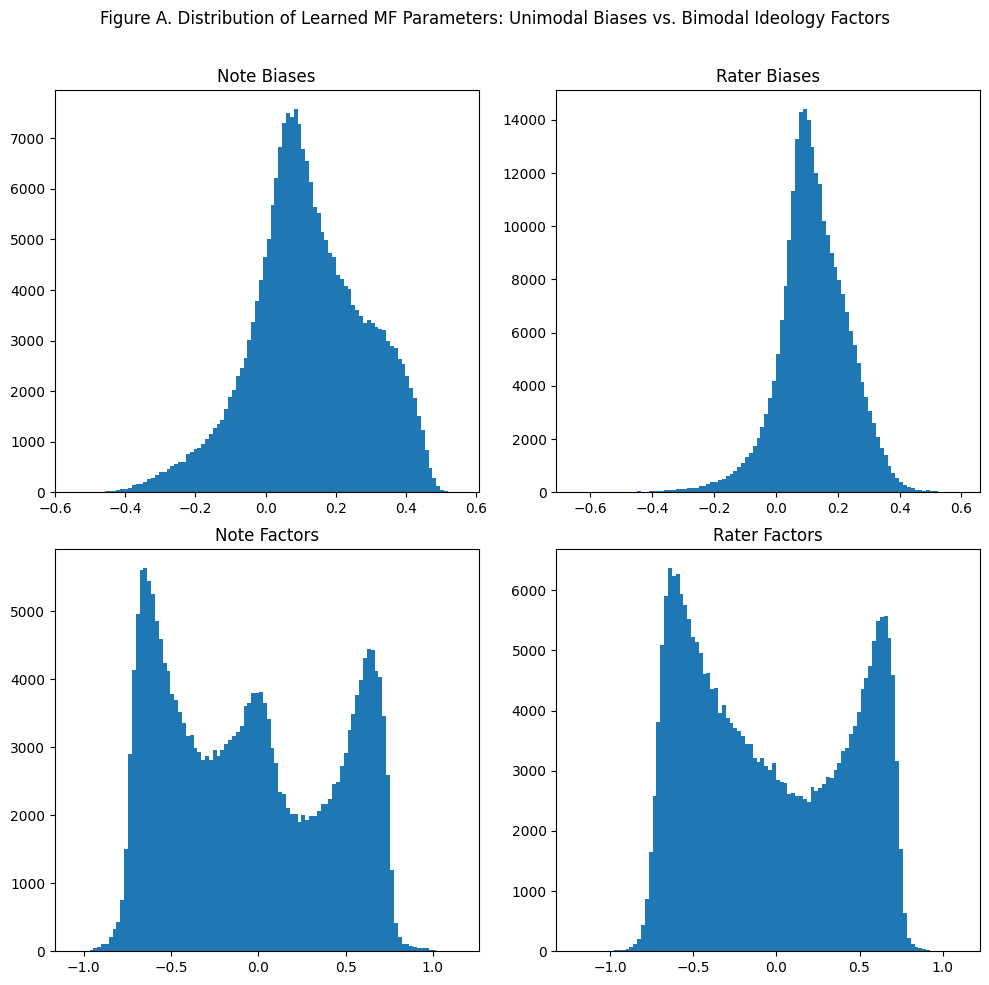

In [13]:
model.show_distribution_of_parameters(title="Figure A. Distribution of Learned MF Parameters: Unimodal Biases vs. Bimodal Ideology Factors")

# Ablation Study - 3 Ranking Methods to Generate Feeds For All Users

1. Normal UCB (quality + exploration term)
2. Threshold-Quality UCB
3. Ideological Complementarity (but no thresholding)
4. Threshold-Quality and Ideological Complementarity

For now, choose $\lambda_1$, $\lambda_2$ to give equal weight to each metric, threshold $\tau=0.2$, timesteps $T = 100$.

# Compare the following rating streams


0. Observed rating stream (in true CN dataset)
1. to 4. generated from each of the feeds above

# Eval Metrics

1. Early-discovery rate
2. Time-to-$m$ ratings on helpful notes
3. Helpful-attentions share
4. Time to diversity

In [14]:
# Pick hyperparameters
T = 40

 # Generate Observed Rating as Stream (map candidate_note_id -> rating_stream of len(T))

In [15]:
#@title create time bins
# 0. created synthetic id's for ease of access 0, ..., 3316
unique_candidate_note_ids = candidate_notes['noteId'].unique()
candidate_note_id_to_synthetic_id = {note_id: i for i, note_id in enumerate(unique_candidate_note_ids)}

# 1. Convert the column to actual Datetime objects
remaining_ratings['createdAtMillis'] = pd.to_datetime(remaining_ratings['createdAtMillis'])

# 2. Determine start and 90th percentile end time
t_start = remaining_ratings['createdAtMillis'].min()
t_end = remaining_ratings['createdAtMillis'].quantile(0.90)

print(f"Start: {t_start}")
print(f"End (90th percentile): {t_end}")

# 3. Divide into T=100 timesteps
# We convert timestamps to integers (int64 nanoseconds) to use np.linspace
T = 100
time_bins_numeric = np.linspace(t_start.value, t_end.value, T + 1)

# Convert back to datetime objects for readability/usage
time_bins = pd.to_datetime(time_bins_numeric)

print(f"Generated {len(time_bins)} time edges.")
print(f"First bin: {time_bins[0]}")
print(f"Last bin: {time_bins[-1]}")

Start: 2024-10-01 00:16:52.598999977
End (90th percentile): 2024-10-02 15:40:52.671200256
Generated 101 time edges.
First bin: 2024-10-01 00:16:52.599000064
Last bin: 2024-10-02 15:40:52.671200256


In [16]:
#@title create map candidate note id -> list of ratings observed (list of length T)

# Initialize the map structure
# Create an entry for every candidate note with a list of Nones
num_bins = len(time_bins) - 1  # Should be 100

observed_stream_map = {nid: [None] * num_bins for nid in range(len(unique_candidate_note_ids))}

# Populate the map
# Group by noteId and bin_idx to efficiently extract chunks

bin_indices = np.searchsorted(time_bins.values, remaining_ratings['createdAtMillis'].values, side='right') - 1

bin_indices = np.clip(bin_indices, 0, num_bins - 1)

remaining_ratings['bin_idx'] = bin_indices

grouped = remaining_ratings.dropna(subset=['bin_idx']).groupby(['noteId', 'bin_idx'])

for (note_id, bin_idx), group in grouped:

    if note_id in candidate_note_id_to_synthetic_id:
        syn_id = candidate_note_id_to_synthetic_id[note_id]

        if syn_id in observed_stream_map:
            idx = int(bin_idx)

            if 0 <= idx < num_bins:
                observed_stream_map[syn_id][idx] = group
            else:
              print('index out of bounds')

In [17]:
#@title #### sample candidate note ratings stream

observed_stream_map[5]

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
                        noteId  \
 41071581  1841127257256935479   
 41712387  1841127257256935479   
 41855717  1841127257256935479   
 42385092  1841127257256935479   
 44578664  1841127257256935479   
 
                                          raterParticipantId  \
 41071581  5C50E22CA8DFDBD9018F45EA89FE91A7C22BA9434E71A5...   
 41712387  72D6B22905D9EE138C5F62796560A1CBF9B93F34AD59F9...   
 41855717  398374366540F13E618A4EF40F69E0EBAEE8C54D906642...   
 42385092  5AEA07F0795318C1D8DA31F7E53D3171E6E4F55C864C16...   
 44578664  73E38B7CCED78515693C2FD31EFA50101A95D5AC8C95E0...   
 
                        createdAtMillis helpfulnessLevel  rating  bin_idx  
 41071581 2024-10-01 15:02:17.408999920          HELPFUL     1.0       37

# Compute note quality and note factor in an online fashion
## single-note regression starting from base-values

In [18]:
def compute_note_parameter_stream(model, observed_stream_map):
    """
    Recomputes note parameters (bias, factor) for every timestep where new ratings arrive,
    using closed-form Ridge Regression.
    """

    # 1. Constants & Artifacts
    REG_FACTOR = 1e-2      # Lambda for note factor
    REG_INTERCEPT = 5e-2   # Lambda for note bias (intercept)
    NEW_USER_BIAS = 0.1
    NEW_USER_FACTOR = 0.0

    # Fetch trained parameters from the model
    artifacts = model.return_model_artifacts()

    # Extract scalars and arrays
    # Ensure mu is a scalar float
    mu = artifacts['mu']
    if hasattr(mu, 'item'):
        mu = mu.item()

    rater_biases = artifacts['rater_bias']
    rater_factors = artifacts['rater_factors']
    rater_id_to_idx = artifacts['rater_id_to_idx']

    # 2. Initialize the result map
    # Structure: { note_id: { timestep: (note_bias, note_factor) } }
    note_quality_stream = {}

    print(f"Starting regression for {len(observed_stream_map)} notes...")

    # 3. Process each note independently
    for note_id, stream in observed_stream_map.items():
        note_quality_stream[note_id] = {}

        # Initialize Sufficient Statistics for Ridge Regression
        # We accumulate these across timesteps (simulating the 'history' of the note)

        # Matrix A = X^T * X (2x2 matrix)
        # Represents the covariance of features [1, v_u]
        A = np.zeros((2, 2))

        # Vector B = X^T * y (2 vector)
        # Represents the dot product of features and targets
        B = np.zeros(2)

        # 4. Iterate through time steps
        for timestep, ratings_df in enumerate(stream):
            # If no new ratings this step, parameters technically don't change
            # But the prompt asks to compute "where new ratings are introduced".
            # If ratings_df is None or empty, we skip solving for this specific step.
            if ratings_df is None or len(ratings_df) == 0:
                continue

            # Update sufficient statistics with new ratings
            for _, row in ratings_df.iterrows():
                rater_id = row['raterParticipantId']
                rating = float(row['rating'])

                # Retrieve fixed user parameters (b_u, v_u)
                if rater_id in rater_id_to_idx:
                    u_idx = rater_id_to_idx[rater_id]
                    b_u = float(rater_biases[u_idx].item())
                    v_u = float(rater_factors[u_idx].item())
                else:
                    b_u = NEW_USER_BIAS
                    v_u = NEW_USER_FACTOR

                # Formulate target y and feature vector x
                # y = r - mu - b_u
                y_val = rating - mu - b_u

                # Update A (X^T * X)
                # Outer product of [1, v_u] with itself:
                # [ 1      v_u  ]
                # [ v_u    v_u^2]
                A[0, 0] += 1.0
                A[0, 1] += v_u
                A[1, 0] += v_u
                A[1, 1] += v_u ** 2

                # Update B (X^T * y)
                # [ 1 * y   ]
                # [ v_u * y ]
                B[0] += y_val
                B[1] += v_u * y_val

            # 5. Solve the Linear System (Ridge Regression)
            # System: (A + Lambda) * theta = B

            # Add regularization terms to the diagonal
            A_reg = A.copy()
            A_reg[0, 0] += REG_INTERCEPT
            A_reg[1, 1] += REG_FACTOR

            try:
                # Solve for theta = [note_bias, note_factor]
                theta = np.linalg.solve(A_reg, B)
                q_n, v_n = theta[0], theta[1]

                # Store the result
                note_quality_stream[note_id][timestep] = (q_n, v_n)

            except np.linalg.LinAlgError:
                # Fallback for singular matrix (rare with regularization)
                note_quality_stream[note_id][timestep] = (0.0, 0.0)

    print("Stream processing complete.")
    return note_quality_stream

# --- Usage ---
note_quality_stream = compute_note_parameter_stream(model, observed_stream_map)

# Check results for the first note found
if note_quality_stream:
    sample_nid = list(note_quality_stream.keys())[0]
    print(f"\nSample Note ID: {sample_nid}")
    print(f"Updates recorded at timesteps: {list(note_quality_stream[sample_nid].keys())}")

Starting regression for 310 notes...
Stream processing complete.

Sample Note ID: 0
Updates recorded at timesteps: [53, 54, 55, 56, 57, 58, 59, 60, 61, 63, 73, 74, 78, 87, 89, 97, 99]


In [19]:
note_quality_stream[0]

{53: (np.float64(0.16921294567768191), np.float64(0.6175724511873442)),
 54: (np.float64(0.5313887720656346), np.float64(0.04007141926731734)),
 55: (np.float64(0.5082106901256208), np.float64(0.026418748696462286)),
 56: (np.float64(0.5605313882122147), np.float64(0.01983042036621245)),
 57: (np.float64(0.5362750901593817), np.float64(0.056342496464480446)),
 58: (np.float64(0.5432507808292165), np.float64(0.04239623413500106)),
 59: (np.float64(0.5433800443672159), np.float64(0.04223485240169691)),
 60: (np.float64(0.5648067624990256), np.float64(0.03725837982939999)),
 61: (np.float64(0.5449024661330772), np.float64(-0.015609407561680147)),
 63: (np.float64(0.54776419438657), np.float64(-0.021386632875842693)),
 73: (np.float64(0.5558425288626986), np.float64(-0.033240794545838406)),
 74: (np.float64(0.4647176239038395), np.float64(0.08658796694567533)),
 78: (np.float64(0.47242867052865184), np.float64(0.06506254180308603)),
 87: (np.float64(0.4786744776956901), np.float64(0.075550

# Evalutation metrics

In [20]:
def compute_and_plot_metrics(list_observed_stream_maps, candidate_notes, list_note_quality_streams, model,
                             candidate_note_id_to_synthetic_id, labels, T=T):
    """
    Computes EDR, TTm, HAS, and TTD metrics for multiple streams and generates comparative plots.

    Args:
        list_observed_stream_maps: List of observed_stream_map dictionaries.
        candidate_notes: DataFrame containing candidate notes metadata.
        list_note_quality_streams: List of note_quality_stream dictionaries.
        model: The trained Matrix Factorization model.
        candidate_note_id_to_synthetic_id: Mapping from real noteId to synthetic ID.
        labels: List of strings identifying each stream (e.g., ['Observed', 'UCB', 'Diversity']).
        T: Number of timesteps.
    """

    # --- 1. COMMON PRE-PROCESSING ---

    # Get Model Artifacts for User Factors
    artifacts = model.return_model_artifacts()
    rater_factors = artifacts['rater_factors'] # Tensor or array
    rater_id_to_idx = artifacts['rater_id_to_idx']

    # Identify Helpful Notes (CRH) and map to synthetic IDs
    helpful_notes_df = candidate_notes[candidate_notes['currentStatus'] == 'CRH']

    # Set of synthetic IDs that are truly helpful (H)
    H_set = set()
    for real_id in helpful_notes_df['noteId'].values:
        if real_id in candidate_note_id_to_synthetic_id:
            H_set.add(candidate_note_id_to_synthetic_id[real_id])

    print(f"Total Helpful (CRH) Notes in Ground Truth: {len(H_set)}")

    # Initialize data structures for plotting results
    results = {
        'EDR': {},
        'TTm': {},
        'HAS': {},
        'TTD': {}
    }

    # Common X-axes definitions
    W_values = np.arange(1, T + 1)
    m_range = np.arange(1, 21)
    deltas = np.linspace(0, 1.0, 100)

    # --- 2. ITERATE OVER STRATEGIES ---

    for i, (observed_map, quality_stream, label) in enumerate(zip(list_observed_stream_maps, list_note_quality_streams, labels)):
        print(f"\nProcessing Strategy: {label}...")

        # Set of ALL candidate synthetic IDs (N) present in this specific stream
        N_set = set(observed_map.keys())

        # --- Build Cumulative History ---
        # Structure: stats[note_id] = { 'counts': [0...T], 'quality': [0...T], 'variance': [0...T] }
        note_stats = {nid: {'counts': np.zeros(T), 'quality': np.zeros(T), 'variance': np.zeros(T)} for nid in N_set}

        current_raters_factors = {nid: [] for nid in N_set}
        current_counts = {nid: 0 for nid in N_set}
        current_quality = {nid: 0.0 for nid in N_set}

        for t in range(T):
            # A. Process new ratings arriving at time t
            for nid in N_set:
                ratings_df = observed_map[nid][t]

                if ratings_df is not None and len(ratings_df) > 0:
                    current_counts[nid] += len(ratings_df)

                    for r_id in ratings_df['raterParticipantId']:
                        if r_id in rater_id_to_idx:
                            u_idx = rater_id_to_idx[r_id]
                            # Assume 1D factor, grab the item
                            fac = rater_factors[u_idx].item()
                            current_raters_factors[nid].append(fac)
                        else:
                            # New user default (0.0)
                            current_raters_factors[nid].append(0.0)

                # B. Update Quality
                if nid in quality_stream and t in quality_stream[nid]:
                    q_val, _ = quality_stream[nid][t]
                    current_quality[nid] = q_val

                # C. Record State
                note_stats[nid]['counts'][t] = current_counts[nid]
                note_stats[nid]['quality'][t] = current_quality[nid]

                # Calculate Variance
                factors = current_raters_factors[nid]
                if len(factors) > 1:
                    note_stats[nid]['variance'][t] = np.var(factors, ddof=1)
                else:
                    note_stats[nid]['variance'][t] = 0.0

        # --- Calculate Metrics for this Strategy ---

        # 1. Early Discovery Rate (EDR)
        TAU = 0.2
        M_EDR = 5
        edr_curve = []
        for W in W_values:
            discovered_count = 0
            for nid in H_set:
                if nid not in note_stats: continue # Note might not exist in this stream
                counts_window = note_stats[nid]['counts'][:W]
                quality_window = note_stats[nid]['quality'][:W]

                condition_met = (counts_window >= M_EDR) & (quality_window > TAU)
                if np.any(condition_met):
                    discovered_count += 1
            edr_curve.append(discovered_count / len(H_set) if len(H_set) > 0 else 0)
        results['EDR'][label] = edr_curve

        # 2. Time-to-m Ratings (TTm)
        ttm_curve = []
        for m in m_range:
            times_for_m = []
            for nid in H_set:
                if nid not in note_stats: continue
                counts = note_stats[nid]['counts']
                indices = np.where(counts >= m)[0]
                if len(indices) > 0:
                    times_for_m.append(indices[0])
            ttm_curve.append(np.median(times_for_m) if len(times_for_m) > 0 else np.nan)
        results['TTm'][label] = ttm_curve

        # 3. Helpful-Attention Share (HAS)
        total_ratings_helpful = sum([note_stats[nid]['counts'][-1] for nid in H_set if nid in note_stats])
        total_ratings_all = sum([note_stats[nid]['counts'][-1] for nid in N_set])
        has_val = total_ratings_helpful / total_ratings_all if total_ratings_all > 0 else 0.0
        results['HAS'][label] = has_val
        print(f"  -> HAS: {has_val:.4f}")

        # 4. Time-to-Diversity (TTD)
        ttd_curve = []
        for delta in deltas:
            times_for_delta = []
            for nid in H_set:
                if nid not in note_stats: continue
                variances = note_stats[nid]['variance']
                indices = np.where(variances >= delta)[0]
                if len(indices) > 0:
                    times_for_delta.append(indices[0])
            ttd_curve.append(np.median(times_for_delta) if len(times_for_delta) > 0 else np.nan)
        results['TTD'][label] = ttd_curve

    # --- 3. COMPARATIVE PLOTTING ---

    # Plot EDR
    plt.figure(figsize=(10, 6))
    for label, curve in results['EDR'].items():
        plt.plot(W_values, curve, label=label, linewidth=2)
    plt.xlabel('Time Window (W)')
    plt.ylabel('Early Discovery Rate (EDR)')
    plt.title(f'Early Discovery Rate (m={M_EDR}, tau={TAU})')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # Plot TTm
    plt.figure(figsize=(10, 6))
    for label, curve in results['TTm'].items():
        plt.plot(m_range, curve, marker='o', label=label, linewidth=2)
    plt.xlabel('m (Number of Ratings)')
    plt.ylabel('Median Time Steps (TTm)')
    plt.title('Time-to-m Ratings')
    plt.xticks(m_range)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # Plot HAS (Bar Chart for Scalar Comparison)
    if len(list_observed_stream_maps) > 1:
      plt.figure(figsize=(8, 6))
      has_labels = list(results['HAS'].keys())
      has_values = list(results['HAS'].values())
      bars = plt.bar(has_labels, has_values, color=['skyblue', 'salmon', 'lightgreen', 'gold'][:len(has_values)])
      plt.ylabel('Helpful-Attention Share')
      plt.title('Helpful-Attention Share (HAS)')
      plt.ylim(0, max(has_values) * 1.2 if has_values else 1.0)
      for bar in bars:
          yval = bar.get_height()
          plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.3f}", ha='center', va='bottom')
      plt.show()

    # Plot TTD
    plt.figure(figsize=(10, 6))
    for label, curve in results['TTD'].items():
        plt.plot(deltas, curve, label=label, linewidth=2) # x=TTD, y=Delta
    plt.xlabel('Diversity Threshold (delta)')
    plt.ylabel('Median Time Steps (TTD)')
    plt.title('Time-to-Diversity')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

Total Helpful (CRH) Notes in Ground Truth: 100

Processing Strategy: Observed Stream...
  -> HAS: 0.3087


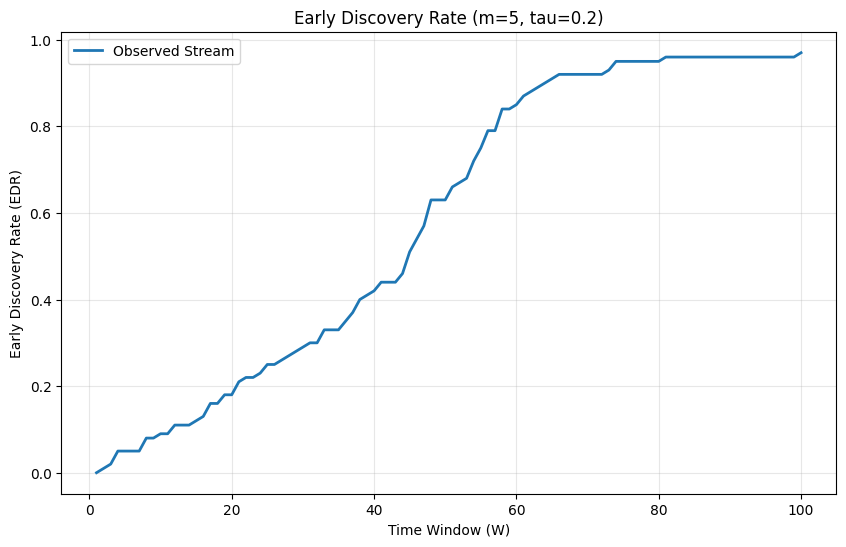

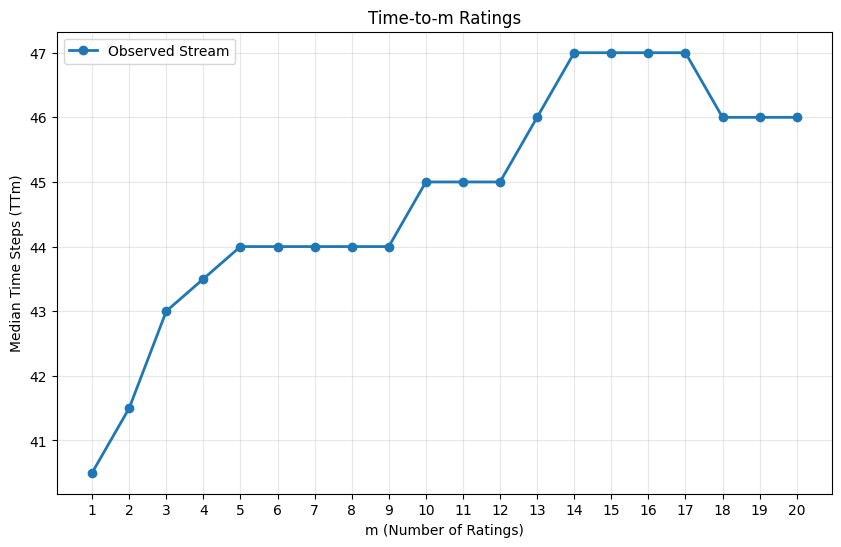

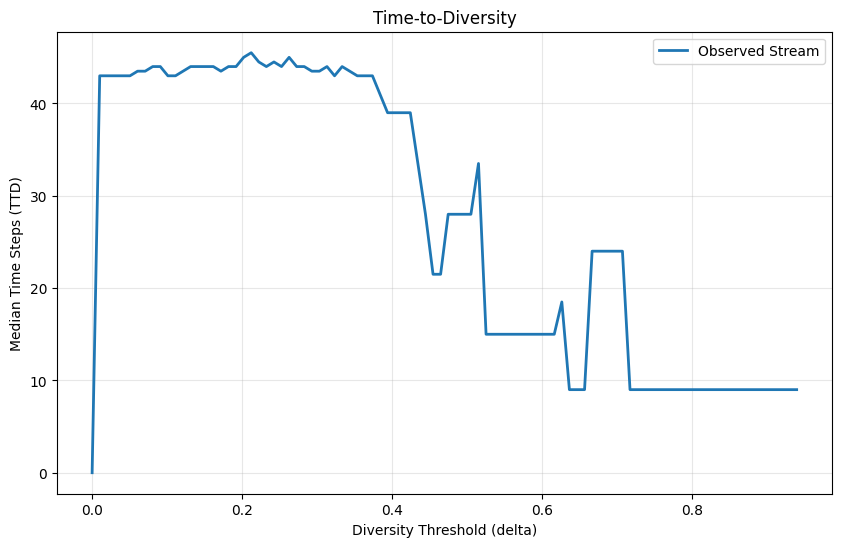

In [21]:
compute_and_plot_metrics([observed_stream_map], candidate_notes, [note_quality_stream], model,
                             candidate_note_id_to_synthetic_id, ["Observed Stream"], T=T)

# Computing UCB "Feeds" for Raters

In [22]:
def get_ratings_on_feed(feed_df, current_note_quality, user_id, c_u, model_artifacts,
                        already_rated_ids, history_map, T=T, params=None):
    """
    Simulates user ratings on a feed based on position decay and user capacity.

    Args:
        feed_df (pd.DataFrame): Ordered dataframe of the feed. Must contain 'noteId'.
        current_note_quality (dict): Map of noteId -> (quality_score, bias).
        user_id (str): The rater's ID.
        c_u (float): Total expected number of ratings this user will give over T steps.
        model_artifacts (dict): Offline trained model ('mu', 'rater_bias', 'rater_factors', etc.)
                                acting as the "Ground Truth" for user preferences.
        already_rated_ids (set): Set of noteIds this user has already rated in the simulation.
                                 Used to prevent duplicate ratings.
        history_map (dict): Dictionary mapping {noteId: rating} from historical data.
                            Used to mimic ground truth ratings if available.
        T (int): Total simulation time steps (default 100).
        params (dict): Config for 'new_user_bias', 'new_user_factor', 'r' (decay).

    Returns:
        list: A list of new ratings generated in this step.
    """
    if params is None: params = {}

    # --- 1. Setup Parameters ---
    decay_r = params.get('r', 0.9)
    new_user_bias = params.get('new_user_bias', 0.0)
    new_user_factor = params.get('new_user_factor', 0.0)

    # Feed limit K (e.g., 30)
    K = len(feed_df)
    if K == 0: return []

    # --- 2. Compute P_0 (Probability of rating rank 0) ---
    # We want the expected number of ratings in this ONE time step to be (c_u / T).
    # E[ratings] = Sum(P(rate|k)) = Sum(P_0 * r^k) for k=0..K-1
    #            = P_0 * (1 - r^K) / (1 - r)

    expected_ratings_per_step = c_u / T

    # Geometric series sum term
    geom_sum = (1.0 - (decay_r ** K)) / (1.0 - decay_r)

    if geom_sum == 0:
        p_0 = 0.0
    else:
        p_0 = expected_ratings_per_step / geom_sum

    # Cap probability at 1.0
    p_0 = min(p_0, 1.0)

    # --- 3. Prepare User Parameters (Ground Truth) ---
    # We retrieve the user's "True" latent factors from the offline model
    # to simulate how they *would* rate an unseen item.
    mu = model_artifacts['mu']
    if hasattr(mu, 'item'): mu = mu.item()

    rater_id_to_idx = model_artifacts['rater_id_to_idx']
    note_id_to_idx = model_artifacts['note_id_to_idx']

    # Get User Factors
    if user_id in rater_id_to_idx:
        u_idx = rater_id_to_idx[user_id]
        b_u = model_artifacts['rater_bias'][u_idx]
        f_u = model_artifacts['rater_factors'][u_idx]
        if hasattr(b_u, 'item'): b_u = b_u.item()
        if hasattr(f_u, 'item'): f_u = f_u.item()
    else:
        b_u = new_user_bias
        f_u = new_user_factor

    generated_ratings = []

    # --- 4. Iterate Feed ---
    # Enumerate gives us the rank k (0, 1, 2...)
    for k, row in enumerate(feed_df.itertuples(index=False)):
        note_id = row.noteId

        # A. Check History (No duplicate ratings)
        if note_id in already_rated_ids:
            continue

        # B. Decide IF they vote (Coin Flip)
        prob_vote = p_0 * (decay_r ** k)

        if np.random.rand() > prob_vote:
            continue # User scrolled past without rating

        # C. Decide WHAT they vote
        final_rating = None

        # Scenario 1: Pair exists in dataset -> Mimic it
        if note_id in history_map:
            final_rating = history_map[note_id]

        # Scenario 2: Pair doesn't exist -> Predict using "Ground Truth" Model
        else:

            if note_id in current_note_quality:
                # n_idx = note_id_to_idx[note_id]

                # Fetch Note Truth
                # In MF, q_n corresponds to the note bias term
                # b_n = model_artifacts['note_bias'][n_idx]
                # f_n = model_artifacts['note_factors'][n_idx]

                # if hasattr(b_n, 'item'): b_n = b_n.item()
                # if hasattr(f_n, 'item'): f_n = f_n.item()

                b_n, f_n = current_note_quality[note_id]

                # Compute raw score: mu + b_u + q_n + (f_u * f_n)
                # q_n here is represented by b_n (note bias)
                raw_score = mu + b_u + b_n + (f_u * f_n)

                # Apply Logistic Function
                pred_prob = 1.0 / (1.0 + np.exp(-raw_score))

                # Thresholding Logic
                HELPFUL_THRESHOLD = 0.6
                NOT_HELPFUL_THRESHOLD = 0.03
                if pred_prob > HELPFUL_THRESHOLD:
                    final_rating = 1.0 # Helpful
                elif pred_prob >= NOT_HELPFUL_THRESHOLD:
                    final_rating = 0.5 # Somewhat Helpful
                elif pred_prob < NOT_HELPFUL_THRESHOLD and pred_prob >=0:
                    final_rating = 0.0 # Not Helpful
            else:
                # Note unknown to offline model (rare in this setup)
                final_rating = 0.0

        # D. Store Rating
        generated_ratings.append({
            'noteId': note_id,
            'raterParticipantId': user_id,
            'rating': final_rating,
            'rank': k
        })

    return generated_ratings

In [23]:
# @title creating UCB feeds

# The four types of feeds. the exploration term and quality term is always present
# - Regular UCB
# - Quality-term thresholded UCB
# - Ideological Complementarity term without quality-thresholding
# - both Threshold-Quality and Ideological Complementarity)

def create_UCB_feeds(user_id, candidate_note_ids, current_note_quality,
                     current_ratings_map, model_artifacts, strategies, params=None):
    """
    Generates 4 variants of UCB-ranked feeds for a specific user.

    Args:
        user_id (str): ID of the user to generate the feed for.
        candidate_note_ids (list): List of note IDs eligible for the feed.
        current_note_quality (dict): Map {noteId: (quality_score, note_factor)}.
                                     Represents q_hat.
        current_ratings_map (dict): Map {noteId: [list_of_rater_ids]}.
                                    Represents R_i^t (set of previous raters).
        model_artifacts (dict): Contains 'rater_factors' and 'rater_id_to_idx'
                                for computing ideology.
        params (dict): Parameters tau, lambda1, lambda2, k.

    Returns:
        dict: A dictionary with keys ['quality_ucb', 'threshold_ucb',
              'ideology_ucb', 'composite_ucb'], each containing the top-k DataFrame.
    """
    if params is None: params = {}

    # --- 1. Setup Parameters ---
    tau = params.get('tau', 0.2)          # Quality Threshold
    lambda1 = params.get('lambda1', 1.0)  # Ideology weight
    lambda2 = params.get('lambda2', 1.0)  # Exploration weight
    k = params.get('k', 20)               # Feed size

    # --- 2. Get Current User's Ideology (v_u) ---
    rater_id_to_idx = model_artifacts['rater_id_to_idx']
    rater_factors = model_artifacts['rater_factors']

    # Default factor if user is new/unknown (usually 0.0)
    v_u = 0.0
    if user_id in rater_id_to_idx:
        u_idx = rater_id_to_idx[user_id]
        val = rater_factors[u_idx]
        v_u = val.item() if hasattr(val, 'item') else val

    # --- 3. Compute Component Terms for All Candidates ---
    note_data = []

    for note_id in candidate_note_ids:

        # A. Note Quality (q_hat)
        # Retrieve from online regression estimates
        if note_id in current_note_quality:
            # Assuming tuple (bias, factor), we take bias as quality
            q_hat = current_note_quality[note_id][0]
            if hasattr(q_hat, 'item'): q_hat = q_hat.item()
        else:
            # Default prior if no ratings yet (e.g., 0.0)
            q_hat = 0.0

        # B. Thresholded Quality (Q)
        # Indicator: 1 if q_hat > tau else 0
        # Note: The formula implies Q = q_hat * indicator, not just the indicator itself.
        indicator = 1.0 if q_hat > tau else 0.0
        Q_term = q_hat * indicator

        # C. Previous Raters (R_i^t)
        previous_raters = current_ratings_map.get(note_id, [])
        count_R = len(previous_raters)

        # D. Ideological Complementarity (E)
        # E = lambda1 * sum((v_u - v_u')^2)
        sum_sq_diff = 0.0

        if count_R > 0:
            # Optimization: If we have many raters, vectorizing this look-up
            # outside the loop is better. For simulation scale, this loop is acceptable.
            for r_prime in previous_raters:
                v_prime = 0.0
                if r_prime in rater_id_to_idx:
                    idx = rater_id_to_idx[r_prime]
                    val = rater_factors[idx]
                    v_prime = val.item() if hasattr(val, 'item') else val

                sum_sq_diff += (v_u - v_prime) ** 2

        E_term = lambda1 * sum_sq_diff

        # E. Exploration (U)
        # U = lambda2 / sqrt(|R| + 1)
        U_term = lambda2 / np.sqrt(count_R + 1)

        # Store terms to compute variants
        note_data.append({
            'noteId': note_id,
            'q_hat': q_hat,    # Raw Quality
            'Q': Q_term,       # Thresholded Quality
            'E': E_term,       # Ideology
            'U': U_term        # Exploration
        })

    # Create DataFrame for easy sorting
    df = pd.DataFrame(note_data)
    if df.empty:
        return {k: pd.DataFrame(columns=['noteId']) for k in strategies}

    # --- 4. Compute 5 Scores ---

    # 1. Pure Note Quality + Exploration
    # S1 = q_hat + U
    df['score_1'] = df['q_hat'] + df['U']

    # 2. Thresholded Quality + Exploration
    # S2 = Q + U
    df['score_2'] = df['Q'] + df['U']

    # 3. Ideological Complementarity + Exploration
    # S3 = q_hat + E + U
    df['score_3'] = df['E'] + df['U']

    # 4. Quality + Ideological Complementarity + Exploration
    # S3 = q_hat + E + U
    df['score_4'] = df['q_hat'] + df['E'] + df['U']

    # 4. Thresholded Quality + Ideological Complementarity + Exploration
    # S4 = Q + E + U (The specific formula requested)
    df['score_5'] = df['Q'] + df['E'] + df['U']

    # --- 5. Rank and Select Top K ---

    feeds = {}

    # Helper to sort and slice
    def get_top_k(score_col):
        return df.sort_values(by=score_col, ascending=False).head(k)[['noteId', score_col]]

    feeds[strategies[0]] = get_top_k('score_1')
    feeds[strategies[1]] = get_top_k('score_2')
    feeds[strategies[2]] = get_top_k('score_3')
    feeds[strategies[3]] = get_top_k('score_4')
    feeds[strategies[4]] = get_top_k('score_5')

    return feeds

# Run Simulation - Create Rating Streams

In [24]:
from tqdm import tqdm

# --- 1. Setup & Initialization ---

# Parameters
T = 40
K_FEED = 10
TAU = 0.2
LAMBDA1 = 1.0
LAMBDA2 = 1.0
DECAY_R = 0.9
SUBSAMPLE_S = 70 # Sample 1/Sth of users per step

# User Capacities (c_u)
user_capacity_map = remaining_ratings['raterParticipantId'].value_counts().to_dict()
active_users = list(user_capacity_map.keys())
print(f"Total Active Users: {len(active_users)}")
print(f"Simulating {len(active_users)//SUBSAMPLE_S} users per step over {T} steps.")

# Ground Truth Lookup (Optimized)
# We pre-group to allow fast access to user history
user_rating_histories = remaining_ratings.groupby('raterParticipantId')
def get_user_history(uid):
    if uid in user_rating_histories.groups:
        # Return dict for O(1) access: {noteId: rating}
        group = user_rating_histories.get_group(uid)
        return dict(zip(group['noteId'], group['rating']))
    return {}

# Initialize Strategies
strategies = ['standard_ucb',
              'threshold_ucb',
              'ideology_ucb',
              'quality_ideology_ucb',
              'theshold_quality_ideology_ucb']

# Data Structures
# stream_map: {strategy: {noteId: {timestep: list_of_ratings}}}
sim_stream_maps = {s: {nid: {} for nid in unique_candidate_note_ids} for s in strategies}

# Quality History (Preserved!)
# {strategy: {noteId: {timestep: (quality, bias)}}}
sim_quality_history = {s: {nid: {} for nid in unique_candidate_note_ids} for s in strategies}

# Current Quality State (for ranking)
# {strategy: {noteId: (quality, bias)}}
current_quality_state = {s: {} for s in strategies}

# Accumulated Rated Sets (Blocklist)
# {strategy: {user_id: set(rated_note_ids)}}
sim_user_rated_sets = {s: {uid: set() for uid in active_users} for s in strategies}

# Stats Counters
stats = {
    s: {'total': 0, 'mimicked': 0, 'generated': 0,
        'helpful': 0, 'somewhat': 0, 'not_helpful': 0}
    for s in strategies
}


# --- 2. Simulation Loop ---

artifacts = model.return_model_artifacts()

for t in tqdm(range(T), desc="Simulation Timesteps"):

    # Select random subset of users for this step
    step_users = np.random.choice(active_users, size=int(len(active_users)/SUBSAMPLE_S), replace=False)

    for strategy in strategies:

        # 1. Collect Ratings for Batch
        step_new_ratings = []

        for user_id in step_users:
            c_u = user_capacity_map[user_id]
            if c_u < 1: continue

            # Scale capacity
            c_u_scaled = c_u * SUBSAMPLE_S

            # Get Data
            history_lookup = get_user_history(user_id)
            already_rated = sim_user_rated_sets[strategy][user_id]

            # Generate Feed
            # if strategy == 'random_ucb':
            #     # Random Feed Logic: Shuffle candidates
            #     shuffled_ids = np.random.permutation(unique_candidate_note_ids)
            #     target_feed = pd.DataFrame({'noteId': shuffled_ids[:K_FEED]})
            # else:
            # UCB Logic
            feeds_dict = create_UCB_feeds(
                user_id,
                unique_candidate_note_ids,
                current_quality_state[strategy],
                {}, # Placeholder for exploration counts map (omitted for speed)
                artifacts,
                strategies=strategies,
                params={'tau': TAU, 'lambda1': LAMBDA1, 'lambda2': LAMBDA2, 'k': K_FEED}
                )
            target_feed = feeds_dict.get(strategy)

            if target_feed is None or target_feed.empty: continue

            # Simulate Interaction
            new_ratings = get_ratings_on_feed(
                target_feed,
                current_quality_state[strategy],
                user_id,
                c_u_scaled,
                artifacts,
                already_rated,
                history_lookup,
                T=T,
                params={'r': DECAY_R}
            )

            if new_ratings:
                step_new_ratings.extend(new_ratings)

                # Update Blocklist & Stats
                for r in new_ratings:
                    sim_user_rated_sets[strategy][user_id].add(r['noteId'])

                    # Stats
                    stats[strategy]['total'] += 1
                    if r['noteId'] in history_lookup:
                        stats[strategy]['mimicked'] += 1
                    else:
                        stats[strategy]['generated'] += 1

                    if r['rating'] == 1.0: stats[strategy]['helpful'] += 1
                    elif r['rating'] == 0.5: stats[strategy]['somewhat'] += 1
                    else: stats[strategy]['not_helpful'] += 1

        # 2. Store Ratings & Prepare Regression
        note_updates = {}
        for r in step_new_ratings:
            nid = r['noteId']
            if t not in sim_stream_maps[strategy][nid]:
                sim_stream_maps[strategy][nid][t] = []
            sim_stream_maps[strategy][nid][t].append(r)

            if nid not in note_updates: note_updates[nid] = []
            note_updates[nid].append(r)

        # 3. Update Quality (Regression)
        # Initialize regression constants
        A_base = np.zeros((2, 2))
        A_base[0,0] = 5e-2; A_base[1,1] = 1e-2
        mu_val = artifacts['mu'].item() if hasattr(artifacts['mu'], 'item') else artifacts['mu']

        # Only update notes that got new ratings
        for nid in note_updates.keys():
            # Gather full history for this note from stream map
            all_rows = []
            for past_t in range(t + 1):
                if past_t in sim_stream_maps[strategy][nid]:
                    all_rows.extend(sim_stream_maps[strategy][nid][past_t])

            if not all_rows: continue

            # Regress
            A = A_base.copy()
            B = np.zeros(2)

            for row in all_rows:
                rid = row['raterParticipantId']
                rating = float(row['rating'])

                if rid in artifacts['rater_id_to_idx']:
                    u_idx = artifacts['rater_id_to_idx'][rid]
                    b_u = artifacts['rater_bias'][u_idx]
                    v_u = artifacts['rater_factors'][u_idx]
                    if hasattr(b_u, 'item'): b_u = b_u.item()
                    if hasattr(v_u, 'item'): v_u = v_u.item()
                else:
                    b_u=0.0; v_u=0.0

                y = rating - mu_val - b_u
                A[0,0] += 1.0
                A[0,1] += v_u
                A[1,0] += v_u
                A[1,1] += v_u**2
                B[0] += y
                B[1] += v_u * y

            try:
                theta = np.linalg.solve(A, B)
                current_quality_state[strategy][nid] = (theta[0], theta[1])
            except:
                pass

        # 4. Save History Snapshot
        # Store (quality, bias) for ALL notes at this timestep
        # For efficiency, only store updates or copy full state?
        # compute_and_plot_metrics likely expects dense history for accurate EDR.
        # We will copy the current state.
        for nid, val in current_quality_state[strategy].items():
            sim_quality_history[strategy][nid][t] = val


# --- 3. Reporting & Visualization ---

print("\n--- Simulation Statistics ---")
print(f"Observed Ratings Count: {len(remaining_ratings)}")
for s in strategies:
    d = stats[s]
    print(f"\nStrategy: {s}")
    print(f"  Total Ratings: {d['total']}")
    print(f"  Mimicked (Ground Truth): {d['mimicked']} ({d['mimicked']/d['total']:.1%})")
    print(f"  Generated (Predicted):   {d['generated']} ({d['generated']/d['total']:.1%})")
    print(f"  Distribution -> Helpful: {d['helpful']}, Somewhat: {d['somewhat']}, Not: {d['not_helpful']}")

# Format for Plotting
formatted_stream_maps = []
formatted_quality_streams = []

for strategy in strategies:
    # Stream Map -> DFs
    s_map = {}
    for nid, time_data in sim_stream_maps[strategy].items():
        s_map[nid] = [None] * T
        for t_step, r_list in time_data.items():
            if r_list:
                s_map[nid][t_step] = pd.DataFrame(r_list)
    formatted_stream_maps.append(s_map)

    # Quality history (already in correct format)
    formatted_quality_streams.append(sim_quality_history[strategy])

# Prepare Comparison Lists
all_stream_maps = [observed_stream_map] + formatted_stream_maps
all_quality_streams = [note_quality_stream] + formatted_quality_streams
all_labels = ['Observed'] + strategies

# print("\nGenerating Evaluation Plots...")
# # Call the metric plotting function
# compute_and_plot_metrics(
#     all_stream_maps,
#     candidate_notes,
#     all_quality_streams,
#     model,
#     candidate_note_id_to_synthetic_id,
#     all_labels,
#     T=T
# )

Total Active Users: 13875
Simulating 198 users per step over 40 steps.


Simulation Timesteps: 100%|██████████| 40/40 [05:08<00:00,  7.70s/it]



--- Simulation Statistics ---
Observed Ratings Count: 24237

Strategy: standard_ucb
  Total Ratings: 21816
  Mimicked (Ground Truth): 247 (1.1%)
  Generated (Predicted):   21569 (98.9%)
  Distribution -> Helpful: 3404, Somewhat: 1416, Not: 16996

Strategy: threshold_ucb
  Total Ratings: 20190
  Mimicked (Ground Truth): 79 (0.4%)
  Generated (Predicted):   20111 (99.6%)
  Distribution -> Helpful: 16518, Somewhat: 2822, Not: 850

Strategy: ideology_ucb
  Total Ratings: 19870
  Mimicked (Ground Truth): 78 (0.4%)
  Generated (Predicted):   19792 (99.6%)
  Distribution -> Helpful: 17458, Somewhat: 1864, Not: 548

Strategy: quality_ideology_ucb
  Total Ratings: 21987
  Mimicked (Ground Truth): 200 (0.9%)
  Generated (Predicted):   21787 (99.1%)
  Distribution -> Helpful: 3426, Somewhat: 1424, Not: 17137

Strategy: theshold_quality_ideology_ucb
  Total Ratings: 20305
  Mimicked (Ground Truth): 71 (0.3%)
  Generated (Predicted):   20234 (99.7%)
  Distribution -> Helpful: 16039, Somewhat: 3286


Regenerating Plots with Aligned IDs...
Total Helpful (CRH) Notes in Ground Truth: 100

Processing Strategy: Observed...
  -> HAS: 0.3404

Processing Strategy: standard_ucb...
  -> HAS: 0.3418

Processing Strategy: threshold_ucb...
  -> HAS: 0.2032

Processing Strategy: ideology_ucb...
  -> HAS: 0.5605

Processing Strategy: quality_ideology_ucb...
  -> HAS: 0.3385

Processing Strategy: theshold_quality_ideology_ucb...
  -> HAS: 0.2135


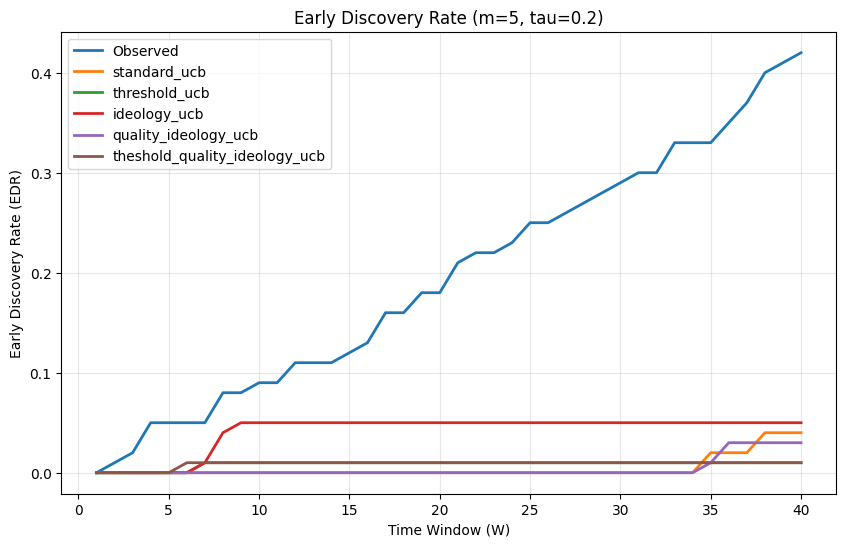

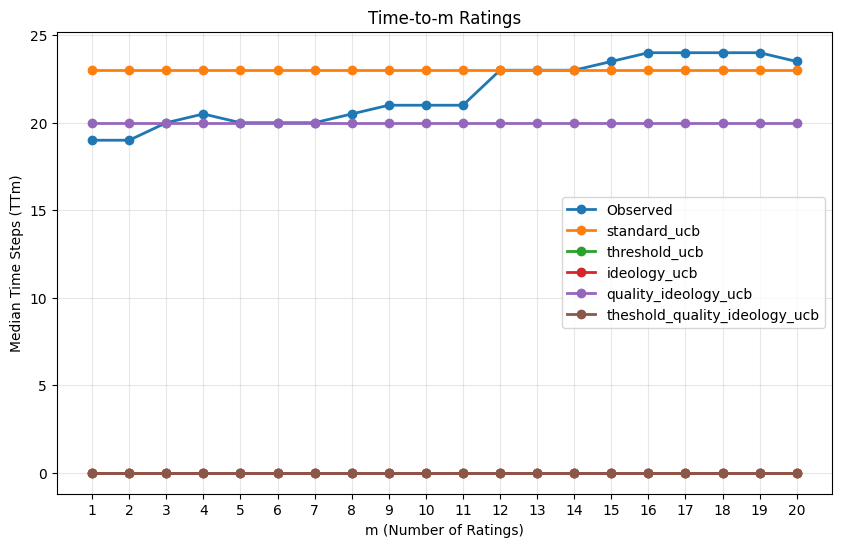

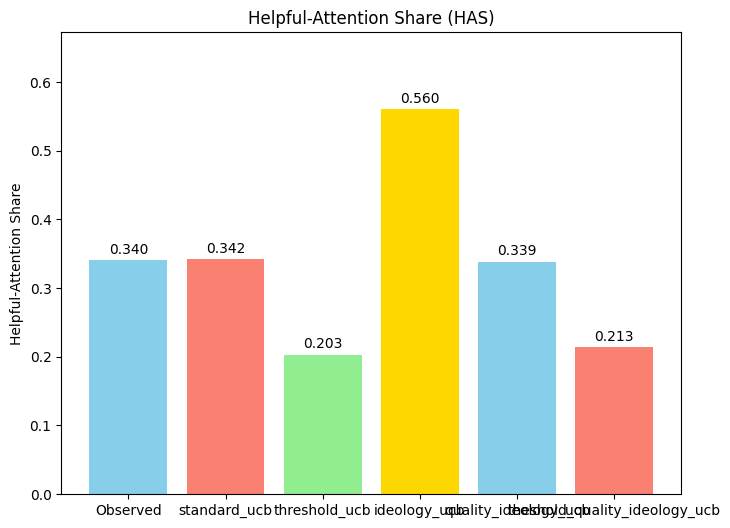

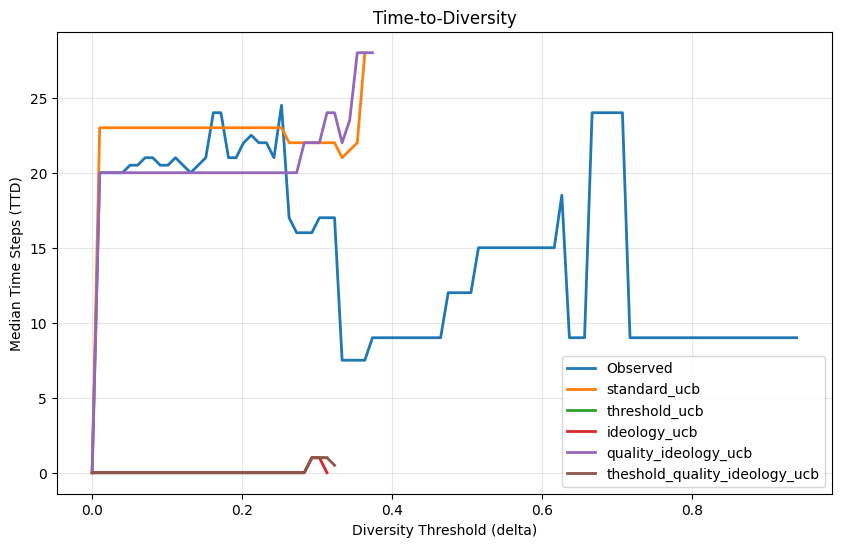

In [25]:
# The plotting function expects Synthetic IDs (0..N-1), but the sim used Real IDs.
# We need to remap the simulation output to match the Observed stream format.

fixed_stream_maps = []
fixed_quality_streams = []

for strategy in strategies:
    # 1. Fix Rating Streams
    # Original map: { real_note_id: [dataframes...] }
    # New map:      { synthetic_id: [dataframes...] }
    s_map_original = sim_stream_maps[strategy]
    s_map_fixed = {}

    for real_id, time_data in s_map_original.items():
        if real_id in candidate_note_id_to_synthetic_id:
            syn_id = candidate_note_id_to_synthetic_id[real_id]

            # Reconstruct the list of T dataframes
            s_map_fixed[syn_id] = [None] * T
            for t_step, r_list in time_data.items():
                if r_list:
                    s_map_fixed[syn_id][t_step] = pd.DataFrame(r_list)

    fixed_stream_maps.append(s_map_fixed)

    # 2. Fix Quality History
    # Original: { real_note_id: { t: (q, b) } }
    # New:      { synthetic_id: { t: (q, b) } }
    q_hist_original = sim_quality_history[strategy]
    q_hist_fixed = {}

    for real_id, history in q_hist_original.items():
        if real_id in candidate_note_id_to_synthetic_id:
            syn_id = candidate_note_id_to_synthetic_id[real_id]
            q_hist_fixed[syn_id] = history

    fixed_quality_streams.append(q_hist_fixed)

# --- Re-run Plotting ---
print("\nRegenerating Plots with Aligned IDs...")

# Use the FIXED lists here
all_stream_maps = [observed_stream_map] + fixed_stream_maps
all_quality_streams = [note_quality_stream] + fixed_quality_streams
all_labels = ['Observed'] + strategies

compute_and_plot_metrics(
    all_stream_maps,
    candidate_notes, # Ensure this is the DataFrame corresponding to the small set
    all_quality_streams,
    model,
    candidate_note_id_to_synthetic_id,
    all_labels,
    T=T
)